In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Airbnb_Open_Data .csv', low_memory=False)

In [5]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23551 entries, 0 to 23550
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              23551 non-null  int64  
 1   NAME                            23475 non-null  object 
 2   host id                         23551 non-null  int64  
 3   host_identity_verified          23455 non-null  object 
 4   host name                       23510 non-null  object 
 5   neighbourhood group             23523 non-null  object 
 6   neighbourhood                   23534 non-null  object 
 7   lat                             23542 non-null  float64
 8   long                            23542 non-null  float64
 9   country                         23463 non-null  object 
 10  country code                    23471 non-null  object 
 11  instant_bookable                23471 non-null  object 
 12  cancellation_policy             

In [7]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [8]:
df.duplicated().value_counts()

,count
False,23551


In [9]:
# Neighbourhood group was 'brookln' instead of 'brooklyn'
df[df["neighbourhood group"] == "brooklin"]


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license


In [10]:
df["neighbourhood group"] = df["neighbourhood group"].replace("brooklin", "brooklyn")

In [11]:
df["neighbourhood group"].value_counts()

,count
neighbourhood group,
Manhattan,10781
Brooklyn,10143
Queens,2090
Bronx,366
Staten Island,141
brookln,1
manhatan,1


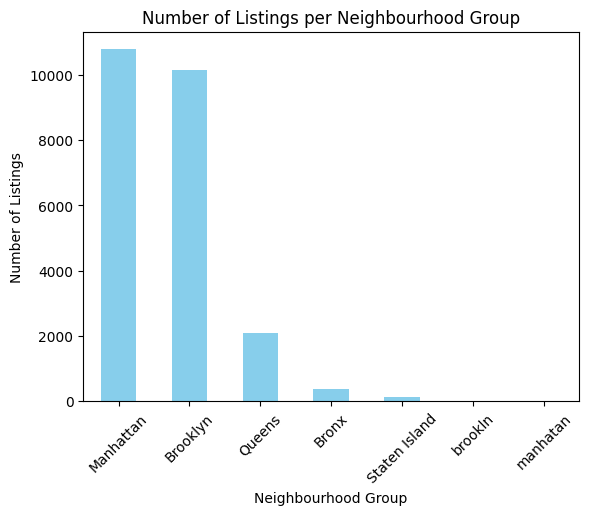

In [12]:
df["neighbourhood group"].value_counts().plot(kind='bar', color='skyblue')
plt.title("Number of Listings per Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()


In [13]:
#Drop duplicate records
df.drop_duplicates(inplace=True)

#Drop house_rules and license columns with insufficient data
cols_to_drop = ['house_rules', 'license']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)


#Remove all dollar signs in the price and service fee columns
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['service fee '] = df['service fee'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

#Remove all commas in the price and service fee columns
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).astype(float)
df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False).astype(float)

# Rename the price and service fee columns to include a dollar sign
df.rename(columns={
    'price': 'price',
    'service fee': 'service fee'
}, inplace=True)

#Drop all records with missing values
df.dropna(inplace=True)

#Change all mismatched data types to the appropriate once.
df['price'] = df['price'].astype(float)
df['service fee'] = df['service fee'].astype(float)
df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'])
df['Construction year'] = df['Construction year'].astype(int)

#Correct the spelling of 'brookln' to 'Brooklyn'
df['neighbourhood group'] = df['neighbourhood group'].replace('brookln', 'Brooklyn')

# Get rid of outliers in the 'availability 365' column data
df = df.drop(df[df['availability 365'] > 365].index)




/tmp/ipykernel_11019/3155104204.py:31: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'])


In [14]:
df.duplicated().value_counts()

,count
False,16961


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16961 entries, 0 to 23549
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              16961 non-null  object        
 1   NAME                            16961 non-null  object        
 2   host id                         16961 non-null  object        
 3   host_identity_verified          16961 non-null  object        
 4   host name                       16961 non-null  object        
 5   neighbourhood group             16961 non-null  object        
 6   neighbourhood                   16961 non-null  object        
 7   lat                             16961 non-null  float64       
 8   long                            16961 non-null  float64       
 9   country                         16961 non-null  object        
 10  country code                    16961 non-null  object        
 11  instant

In [16]:
df.columns.tolist()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'service fee ']

In [17]:
df.describe()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,service fee
count,16961.000000,16961.000000,16961.000000,16961.000000,16961.000000,16961.000000,16961.000000,16961,16961.000000,16961.000000,16961.000000,16961.000000,16961.000000
mean,40.728629,-73.955040,2012.493485,621.245092,124.250752,7.077767,40.909852,2018-05-02 06:01:30.419196928,0.978899,2.995873,3.316314,153.661459,124.250752
min,40.508680,-74.239860,2003.000000,50.000000,10.000000,-12.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000,10.000000
25%,40.688520,-73.982560,2008.000000,329.000000,66.000000,2.000000,4.000000,2017-04-21 00:00:00,0.110000,2.000000,1.000000,40.000000,66.000000
50%,40.722120,-73.956810,2012.000000,617.000000,123.000000,3.000000,14.000000,2019-01-02 00:00:00,0.370000,3.000000,1.000000,145.000000,123.000000
75%,40.763830,-73.940160,2017.000000,913.000000,183.000000,5.000000,56.000000,2019-06-17 00:00:00,1.370000,4.000000,2.000000,259.000000,183.000000
max,40.908040,-73.725820,2022.000000,1200.000000,240.000000,1250.000000,629.000000,2022-05-21 00:00:00,16.220000,5.000000,121.000000,365.000000,240.000000
std,0.054134,0.041151,5.763026,334.265585,66.855207,22.602644,59.225372,NaN,1.344591,1.417414,10.861309,119.258559,66.855207


In [18]:
# what are the different types in the Dataset?
property_type = df['room type'].value_counts().to_frame()
property_type

,count
room type,
Entire home/apt,9305
Private room,7418
Shared room,238


Text(0.5, 1.0, 'Property Types and their count in the Dataset')

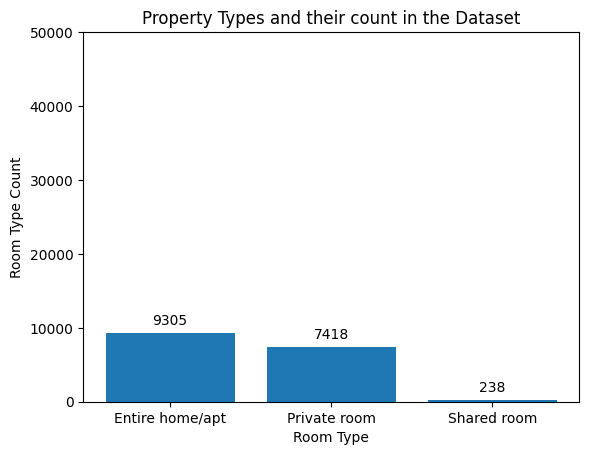

In [19]:
# Room type count plotted on a barchart
room_type_bar = plt.bar(property_type.index, property_type.loc[:, "count"])
plt.bar_label(room_type_bar, labels=property_type.loc[:, "count"], padding=4)
plt.ylim([0, 50000])
plt.xlabel('Room Type')
plt.ylabel('Room Type Count')
plt.title('Property Types and their count in the Dataset')

In [20]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Manhattan,7522
Brooklyn,7430
Queens,1611
Bronx,291
Staten Island,107


Text(0.5, 1.0, 'Which Neighborhood Groups has the highest number of Listings')

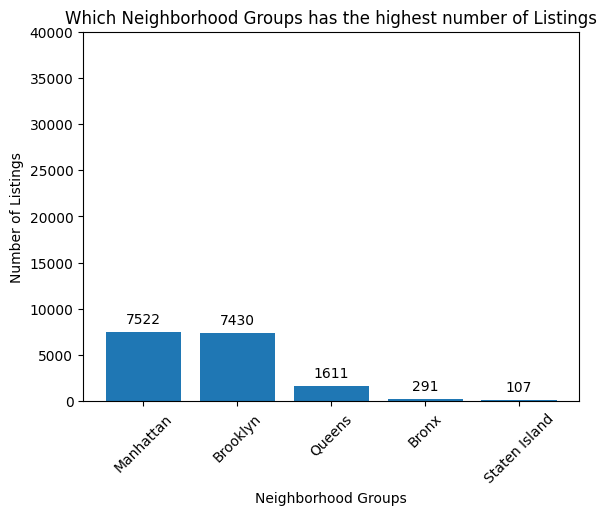

In [21]:
# Which neighborhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:, "count"])
plt.bar_label(hood_group_bar, labels=hood_group.loc[:, "count"], padding=4)
plt.ylim([0, 40000])
plt.xlabel('Neighborhood Groups')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.title('Which Neighborhood Groups has the highest number of Listings')

Text(0.5, 1.0, 'Average Price per Listings ($) in each Neighborhood Group')

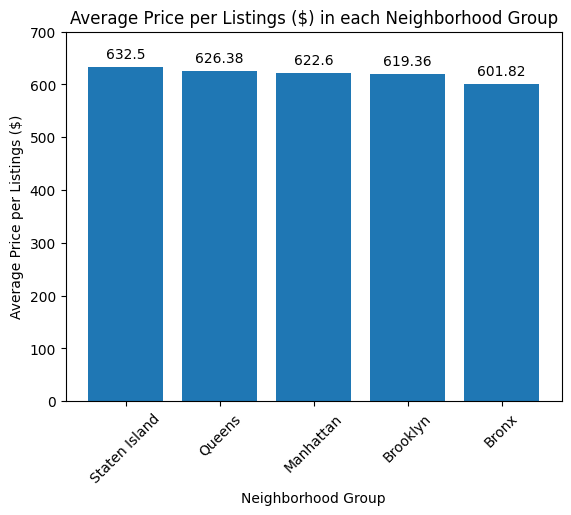

In [22]:
# Which neighborhoods group have the highest average prices for Airbnb listings?
avg_price = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False).to_frame()
avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:, 'price'])
plt.bar_label(avg_price_bar, labels=round(avg_price.loc[:, 'price'], 2), label_type='edge', padding=4)
plt.ylim([0, 700])
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price per Listings ($)')
plt.xticks(rotation=45)
plt.title('Average Price per Listings ($) in each Neighborhood Group')

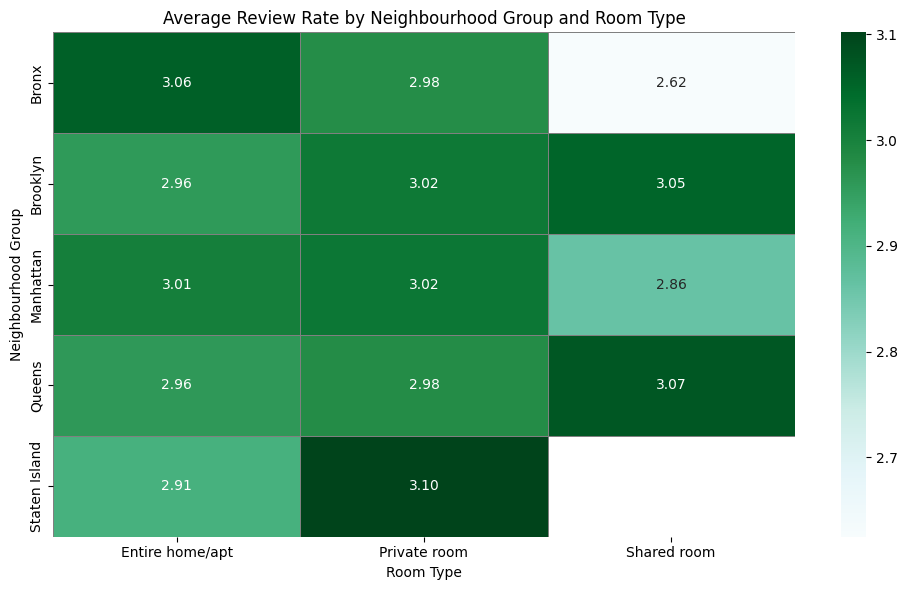

In [23]:
# Average Review Rate by Neighbourhood Group and Room Type
heatmap_data = df.pivot_table(values='review rate number', index='neighbourhood group', columns='room type', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='BuGn', fmt='.2f', linewidths=0.5, linecolor='gray')
plt.title('Average Review Rate by Neighbourhood Group and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Neighbourhood Group')
plt.tight_layout()
plt.show()


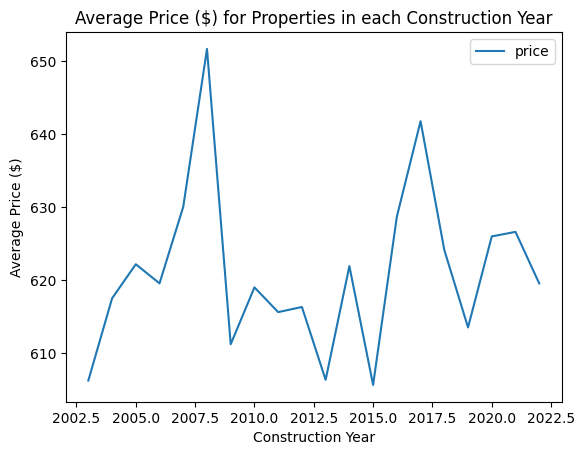

In [24]:
#Is there a relationship between the construction year of property and price?
df.groupby(df['Construction year'])['price'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.title('Average Price ($) for Properties in each Construction Year');

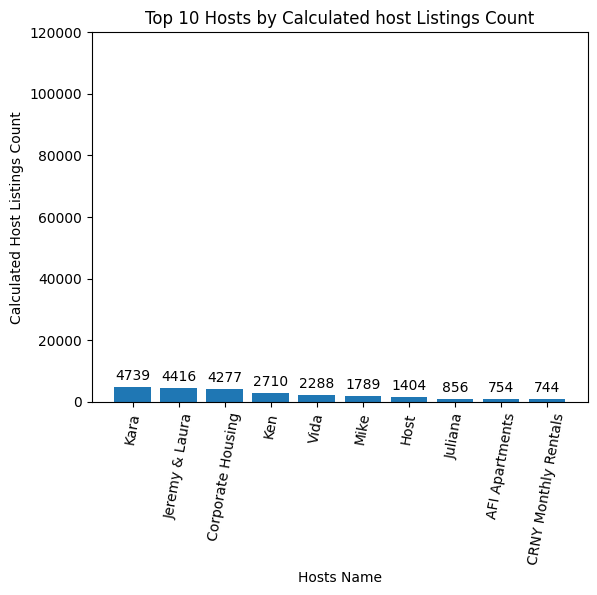

In [25]:
#Who are the top 10 hosts by calculated host listings count?
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:, 'calculated host listings count']);
plt.bar_label(hosts_bar, label = hosts.loc[:, 'calculated host listings count'], label_type = 'edge', padding = 3);
plt.xlabel('Hosts Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation = 80);
plt.ylim([0, 120000]);
plt.title('Top 10 Hosts by Calculated host Listings Count');

In [26]:
#Are hosts with verified identities more likely to receive positive reviews?
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
verified,2.997510
unconfirmed,2.994254


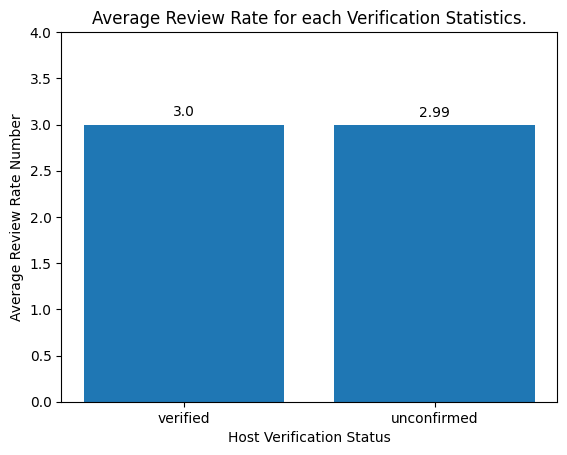

In [27]:
review_bar = plt.bar(review.index, review.loc[:, "review rate number"]);
plt.bar_label(review_bar, labels = round(review.loc[:, "review rate number"], 2), padding = 4);
plt.ylim([0,4]);
plt.xlabel('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate for each Verification Statistics.');

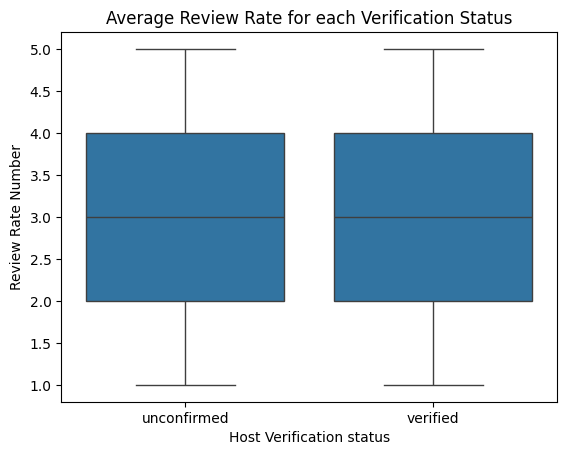

In [28]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = "host_identity_verified", y = "review rate number", color = base_color);
plt.xlabel('Host Verification status');
plt.ylabel('Review Rate Number');
plt.title('Average Review Rate for each Verification Status');

In [29]:
#Is there a correlation between the price of a listing and its service fee?
df['price'].corr(df['service fee'])

np.float64(0.9999910520271683)

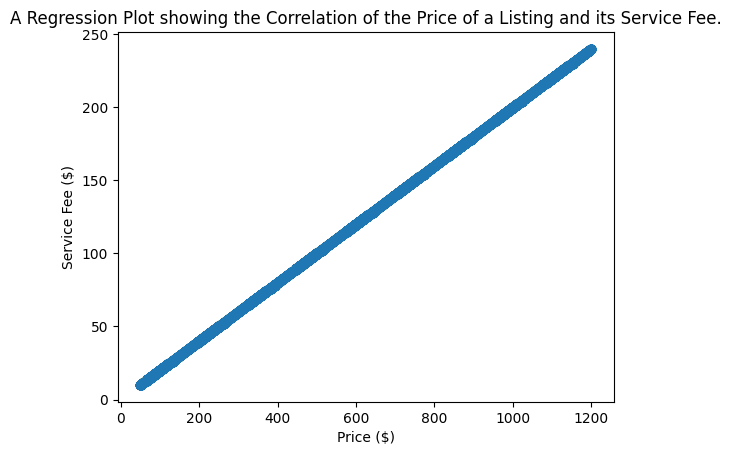

In [35]:
sns.regplot(df, x = 'price', y = 'service fee');
plt.xlabel('Price ($)');
plt.ylabel('Service Fee ($)');
plt.title('A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee.');

In [36]:
#What is the average review rate number (e.g, stars) for listings, and does it vary based on the neighbourhood group and room type?
ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.060000
                    Private room               2.978142
                    Shared room                2.625000
Brooklyn            Entire home/apt            2.958291
                    Private room               3.016745
                    Shared room                3.053191
Manhattan           Entire home/apt            3.006569
                    Private room               3.021434
                    Shared room                2.862385
Queens              Entire home/apt            2.959877
                    Private room               2.979701
                    Shared room                3.074074
Staten Island       Entire home/apt            2.913793
                    Private room               3.102041

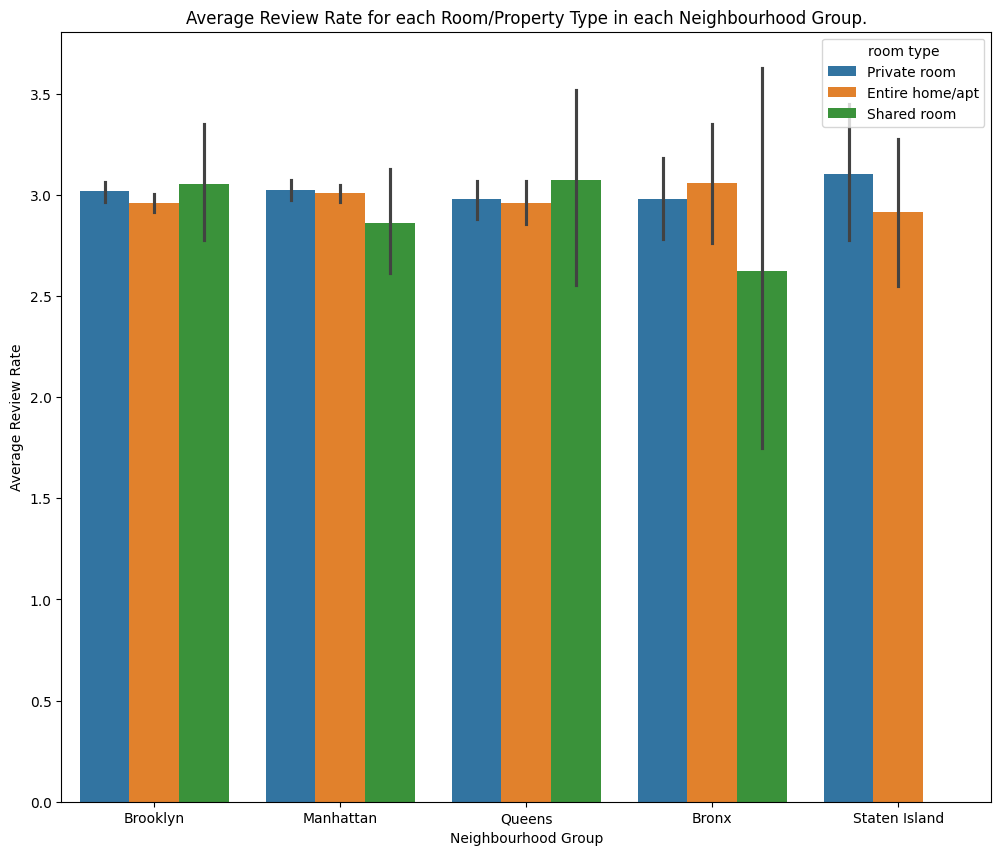

In [37]:
plt.figure(figsize = [12,10]);
sns.barplot(data = df, x = 'neighbourhood group', y = 'review rate number', hue = 'room type' );
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate');
plt.title('Average Review Rate for each Room/Property Type in each Neighbourhood Group.');

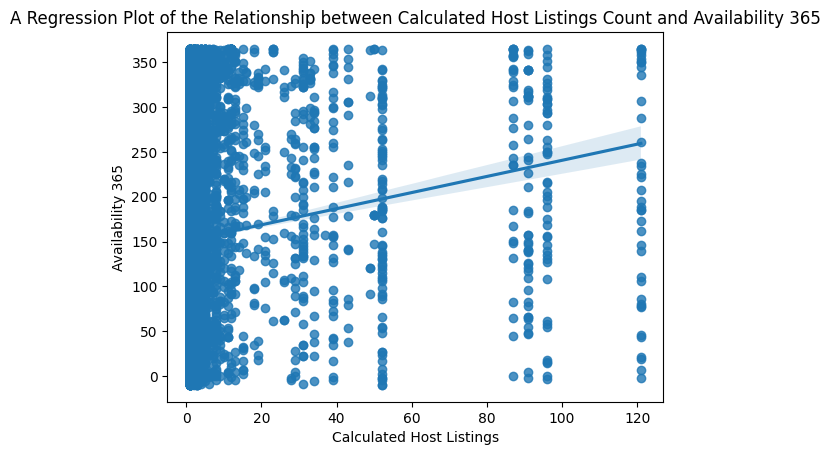

In [38]:
#Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?
sns.regplot(df, x = 'calculated host listings count', y = 'availability 365');
plt.xlabel('Calculated Host Listings');
plt.ylabel('Availability 365');
plt.title('A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365');

In [39]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.08195101860717299)